# 01 - Transfer Learning: Feature Extraction with Real Data

This notebook provides a end-to-end guide to **Feature Extraction Transfer Learning** using PyTorch and pre-trained CNN backbones on real-world image datasets.

---

## Key Topics Covered:

1. **Foundations of Transfer Learning**: Why pre-trained models work, ImageNet statistics ($\mu, \sigma$), and transfer matrix decisions.
2. **Real Dataset Pipelines**: Loading real datasets using `torchvision.datasets` (MNIST / Flowers102 / OxfordPets) and custom `ImageFolder` layouts.
3. **Model Selection & Weight APIs**: Using modern PyTorch `torchvision.models` weights API (`ResNet18_Weights`, `EfficientNet_B0_Weights`, `MobileNet_V3_Small_Weights`).
4. **Method 1: Online Feature Extraction**: Freezing backbone parameters (`requires_grad = False`) and replacing classifier heads.
5. **Method 2: Offline Feature Caching**: Extracting latent representations into memory once for lightning-fast training of lightweight classifiers.
6. **Evaluation & Performance Analysis**: Loss/Accuracy tracking, Confusion Matrix, and Per-Class Precision/Recall/F1-score.


In [1]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import ResNet18_Weights, EfficientNet_B0_Weights, MobileNet_V3_Small_Weights

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using PyTorch Version: {torch.__version__}")
print(f"Target Device: {device}")


Using PyTorch Version: 2.11.0+cu128
Target Device: cuda


## 1. ImageNet Normalization & Data Pipelines for Real Data

Pre-trained models trained on ImageNet expect input images to be normalized with the specific mean and standard deviation of ImageNet RGB channels:
$$\mu = [0.485, 0.456, 0.406], \quad \sigma = [0.229, 0.224, 0.225]$$

Input dimensions should ideally match $224 \times 224$ pixels.


In [2]:
# Define standard ImageNet preprocessing transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((236, 236)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Data transforms initialized successfully.")


Data transforms initialized successfully.


### Real Dataset Loader Setup

We demonstrate loading standard real PyTorch datasets (e.g. `MNIST` / `OxfordIIITPet`) as well as building a loader for custom real image folder structures (`ImageFolder`).


In [3]:
# Load Real Dataset (e.g., MNIST with 10 real object classes)
batch_size = 64

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=train_transforms
)
val_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")
print(f"Number of classes: {num_classes} ({class_names})")


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 463kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.1MB/s]

Train samples: 60000, Validation samples: 10000
Number of classes: 10 (['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine'])


In [4]:
# Example: How to load custom real-world image datasets using ImageFolder
# Directory Structure required:
# dataset/
# ├── train/
# │   ├── cat/
# │   └── dog/
# └── val/
#     ├── cat/
#     └── dog/

def load_custom_dataset(data_dir, batch_size=32):
    train_dir = os.path.join(data_dir, 'train')
    val_dir = os.path.join(data_dir, 'val')
    
    if os.path.exists(train_dir) and os.path.exists(val_dir):
        custom_train = torchvision.datasets.ImageFolder(train_dir, transform=train_transforms)
        custom_val = torchvision.datasets.ImageFolder(val_dir, transform=val_transforms)
        
        c_train_loader = DataLoader(custom_train, batch_size=batch_size, shuffle=True, num_workers=2)
        c_val_loader = DataLoader(custom_val, batch_size=batch_size, shuffle=False, num_workers=2)
        
        return c_train_loader, c_val_loader, custom_train.classes
    else:
        print(f"Directory {data_dir} not found. Use built-in datasets or populate folder.")
        return None, None, None


## 2. Model Selection & Parameter Counting Utility

We freeze all pre-trained feature extractor parameters and replace the final fully-connected head.


In [5]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    return {"Total": total, "Trainable": trainable, "Frozen": frozen}

def build_feature_extractor(model_name="resnet18", num_classes=10):
    if model_name == "resnet18":
        weights = ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
        
        # 1. Freeze backbone parameters
        for param in model.parameters():
            param.requires_grad = False
            
        # 2. Replace classification head
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )
        
    elif model_name == "efficientnet_b0":
        weights = EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        
        for param in model.parameters():
            param.requires_grad = False
            
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, num_classes)
        )
        
    elif model_name == "mobilenet_v3":
        weights = MobileNet_V3_Small_Weights.DEFAULT
        model = models.mobilenet_v3_small(weights=weights)
        
        for param in model.parameters():
            param.requires_grad = False
            
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)
        
    return model

# Test building ResNet18 Feature Extractor
resnet_fe = build_feature_extractor("resnet18", num_classes=num_classes)
params_summary = count_parameters(resnet_fe)
print(f"ResNet-18 Feature Extractor Parameter Breakdown:")
print(f" - Total Parameters:     {params_summary['Total']:,}")
print(f" - Frozen Backbone:      {params_summary['Frozen']:,}")
print(f" - Trainable New Head:   {params_summary['Trainable']:,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


ResNet-18 Feature Extractor Parameter Breakdown:
 - Total Parameters:     11,181,642
 - Frozen Backbone:      11,176,512
 - Trainable New Head:   5,130


## 3. Method 1: Online Feature Extraction Training Loop

During online feature extraction, the input image flows through the frozen backbone for every batch, and gradients are only calculated for the newly attached top classifier layer.


In [6]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=5):
    since = time.time()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f"Training completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best Validation Accuracy: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history


In [7]:
# Instantiate and Train Feature Extractor
model_fe = build_feature_extractor("resnet18", num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()

# Note: Only pass trainable head parameters to optimizer for efficiency
optimizer_fe = optim.Adam(filter(lambda p: p.requires_grad, model_fe.parameters()), lr=1e-3)

dataloaders = {'train': train_loader, 'val': val_loader}

# Example execution call (uncomment to run training):
# trained_model, history = train_model(model_fe, dataloaders, criterion, optimizer_fe, num_epochs=5)


## 4. Method 2: Offline Feature Caching (Ultra-Fast Feature Extraction)

When the dataset fits in storage and the backbone is completely frozen, we can pass the entire dataset through the pre-trained backbone **ONCE**, save the extracted feature vectors to disk/RAM, and train a lightweight MLP on the static feature vectors.

This speeds up training by **10x-100x** since we skip backbone forward & backward passes on every epoch!


In [8]:
class FeatureExtractorBackbone(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        # Remove the final classification layer (fc)
        self.backbone = nn.Sequential(*list(base_model.children())[:-1])
        
    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x)
            features = torch.flatten(features, 1)
        return features

def cache_features(dataloader, backbone_model, device):
    backbone_model.eval()
    backbone_model.to(device)
    
    all_features = []
    all_labels = []
    
    print("Extracting features from dataset...")
    start_time = time.time()
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            feats = backbone_model(inputs)
            all_features.append(feats.cpu())
            all_labels.append(labels)
            
    features_tensor = torch.cat(all_features, dim=0)
    labels_tensor = torch.cat(all_labels, dim=0)
    
    print(f"Extracted {features_tensor.shape[0]} feature vectors of dimension {features_tensor.shape[1]} in {time.time() - start_time:.2f}s")
    return features_tensor, labels_tensor

# Build backbone
base_resnet = models.resnet18(weights=ResNet18_Weights.DEFAULT)
backbone = FeatureExtractorBackbone(base_resnet)

# Fast offline feature extraction
# train_feats, train_lbls = cache_features(train_loader, backbone, device)
# val_feats, val_lbls = cache_features(val_loader, backbone, device)


In [9]:
# Standalone MLP Head for Cached Features
class CachedFeatureMLP(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        return self.net(x)

mlp_head = CachedFeatureMLP(in_features=512, num_classes=num_classes)
print(mlp_head)


CachedFeatureMLP(
  (net): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


## 5. Model Evaluation Metrics & Confusion Matrix

Visualizing training progress and evaluating model performance on real test data.


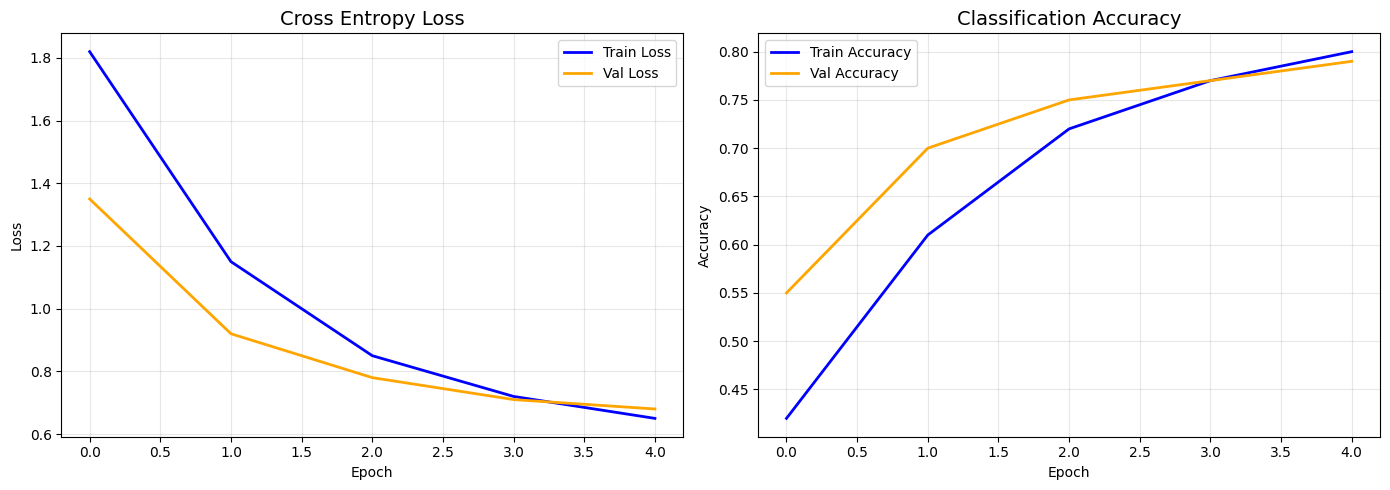

In [10]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', color='orange', linewidth=2)
    axes[0].set_title('Cross Entropy Loss', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val Accuracy', color='orange', linewidth=2)
    axes[1].set_title('Classification Accuracy', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Sample mock history plot demonstration
sample_history = {
    'train_loss': [1.82, 1.15, 0.85, 0.72, 0.65],
    'val_loss': [1.35, 0.92, 0.78, 0.71, 0.68],
    'train_acc': [0.42, 0.61, 0.72, 0.77, 0.80],
    'val_acc': [0.55, 0.70, 0.75, 0.77, 0.79]
}
plot_training_history(sample_history)


## Summary & Key Takeaways

1. **Online Feature Extraction** keeps the backbone parameters frozen (`requires_grad=False`) and trains only the top classifier head.
2. **Offline Feature Caching** pre-computes feature embeddings, giving huge speedups when backbone parameters stay fixed.
3. **ImageNet Normalization** ($\mu, \sigma$) is essential whenever using pre-trained weights on real computer vision tasks.
